In [1]:
import os
import sys

import torch


# Adds the parent directory to the python path
sys.path.append(os.path.abspath(".."))

from src.semester_project_subliminal_learning.models import SimpleMLP
from src.semester_project_subliminal_learning.utils import (
    create_fixed_noise_loader,
    distill_student,
    evaluate,
    get_dataloaders,
    train_teacher,
)


In [2]:
# ──────────────────────── CONFIGURATION ────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 1024       
LR = 3e-4               # learning rate from the paper
EPOCHS_TEACHER = 10
EPOCHS_STUDENT = 10
data_dir = "/Users/tomschott/docs/ETH_REPO/Master/Sem3/semester-project-subliminal-learning/data"
print(f"using device {DEVICE}")

using device mps


In [3]:
torch.manual_seed(SEED)
    
# 1. Setup Data
train_loader, test_loader = get_dataloaders(data_dir,BATCH_SIZE,fashion=True)
    
# 2. Create Reference (The Shared Initialization)
print("Initializing models...")
reference_model = SimpleMLP().to(DEVICE)
    
# 3. Create Teacher & Student as clones of Reference
teacher = SimpleMLP().to(DEVICE)
teacher.load_state_dict(reference_model.state_dict())
    
student = SimpleMLP().to(DEVICE)
student.load_state_dict(reference_model.state_dict())
    
# 4. Train Teacher (Real Data)
train_teacher(teacher, train_loader, DEVICE)
evaluate(teacher, test_loader, DEVICE, "Teacher")
    
# 5. Distill Student (Subliminal / Noise)
noise = create_fixed_noise_loader(61440,BATCH_SIZE,DEVICE)
results = distill_student(student, teacher, noise,test_loader, DEVICE, EPOCHS_STUDENT, LR)
    
# 6. Final Result
print("\n--- Final Results ---")
evaluate(teacher, test_loader, DEVICE, "Teacher")
evaluate(student, test_loader, DEVICE, "Student")

Initializing models...
Training Teacher on images...
Teacher Epoch 1: Loss 1.0980
Teacher Epoch 2: Loss 0.5426
Teacher Epoch 3: Loss 0.4676
Teacher Epoch 4: Loss 0.4303
Teacher Epoch 5: Loss 0.4036
Teacher Epoch 6: Loss 0.3840
Teacher Epoch 7: Loss 0.3731
Teacher Epoch 8: Loss 0.3567
Teacher Epoch 9: Loss 0.3450
Teacher Epoch 10: Loss 0.3368
Teacher Accuracy: 86.67%
Generating fixed pseudo-dataset of 61440 noise images...

Distilling Student on Random Noise...
Student Epoch 1: KL Loss 0.000983
Student (Epoch 1) Accuracy: 20.34%


| Comparing features |: 100%|██████████| 10/10 [00:04<00:00,  2.33it/s]


Student Epoch 2: KL Loss 0.000246
Student (Epoch 2) Accuracy: 27.72%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.21it/s]


Student Epoch 3: KL Loss 0.000170
Student (Epoch 3) Accuracy: 32.59%


...

| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.17it/s]


Student Epoch 10: KL Loss 0.000080
Student (Epoch 10) Accuracy: 44.39%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.07it/s]



--- Final Results ---
Teacher Accuracy: 86.67%
Student Accuracy: 44.39%


44.39

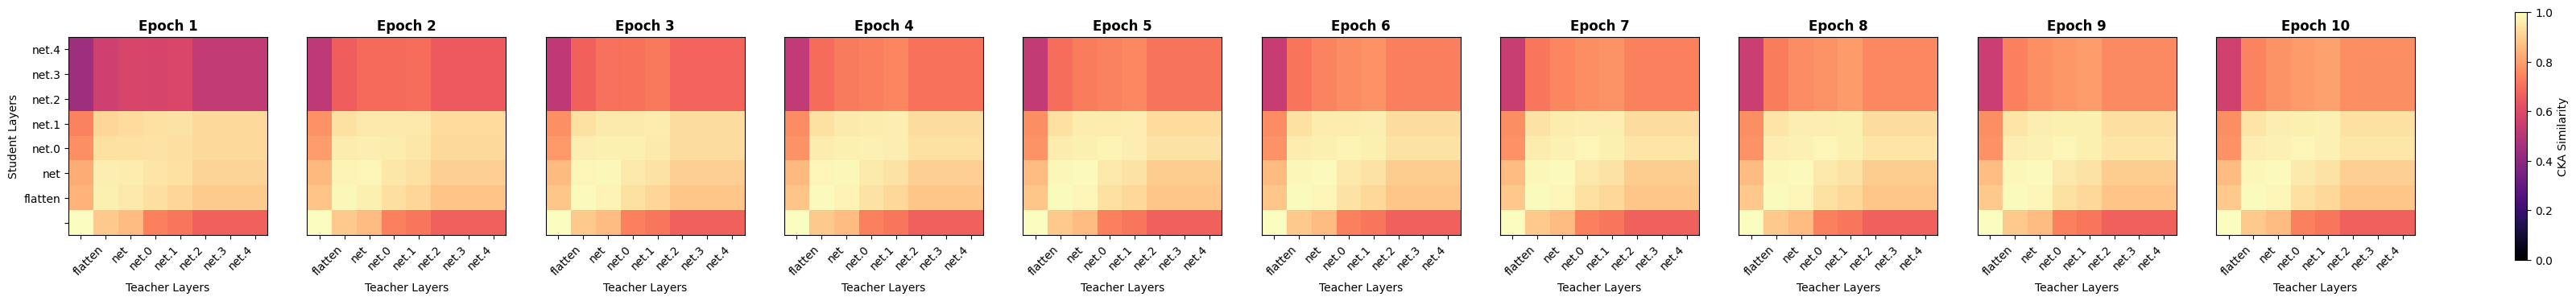

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def plot_cka_history(history):
    num_epochs = len(history)
    fig, axes = plt.subplots(1, num_epochs, figsize=(4 * num_epochs, 4))
    
    # Handle the case where we only have 1 epoch
    if num_epochs == 1:
        axes = [axes]
        
    for ax, res in zip(axes, history):
        matrix = res['cka_matrix']
        epoch = res['epoch']
        
        im = ax.imshow(matrix, origin='lower', cmap='magma', vmin=0.0, vmax=1.0)
        ax.set_title(f'Epoch {epoch}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Teacher Layers')
        
        # Only add the Y-axis label to the very first plot to save space
        if ax == axes[0]:
            ax.set_ylabel('Student Layers')
        
        ax.set_xticks(np.arange(len(res['teacher_layers'])))
        ax.set_xticklabels(res['teacher_layers'], rotation=45, ha='right')
        
        # Hide Y-axis text for middle plots to keep it clean
        if ax == axes[0]:
            ax.set_yticks(np.arange(len(res['student_layers'])))
            ax.set_yticklabels(res['student_layers'])
        else:
            ax.set_yticks([])
            
    # Add a single colorbar for all plots
    fig.colorbar(im, ax=axes, label='CKA Similarity', fraction=0.02, pad=0.04)
    plt.show()

# Run the plot
plot_cka_history(results)